Selected 44 thermalization states.


,Run_ID,Therm_kT,rho_liquid,rho_gas,rho_gas_unc
0,20260915173225,0.86,0.715765,0.020711,0.00026
1,20260915173427,0.86,0.716306,0.020359,0.000272
2,20260915173627,0.86,0.713656,0.020874,0.00033
3,20260915173827,0.86,0.71347,0.018954,0.000311
4,20260915174027,0.86,0.714967,0.020446,0.000358
5,20260915174228,0.86,0.713072,0.02132,0.000442
6,20260915174430,0.88,0.703266,0.023396,0.000289
7,20260915174630,0.88,0.700387,0.023085,0.000329
8,20260915174829,0.88,0.699625,0.02546,0.000378
9,20260915175032,0.88,0.701079,0.023764,0.000389


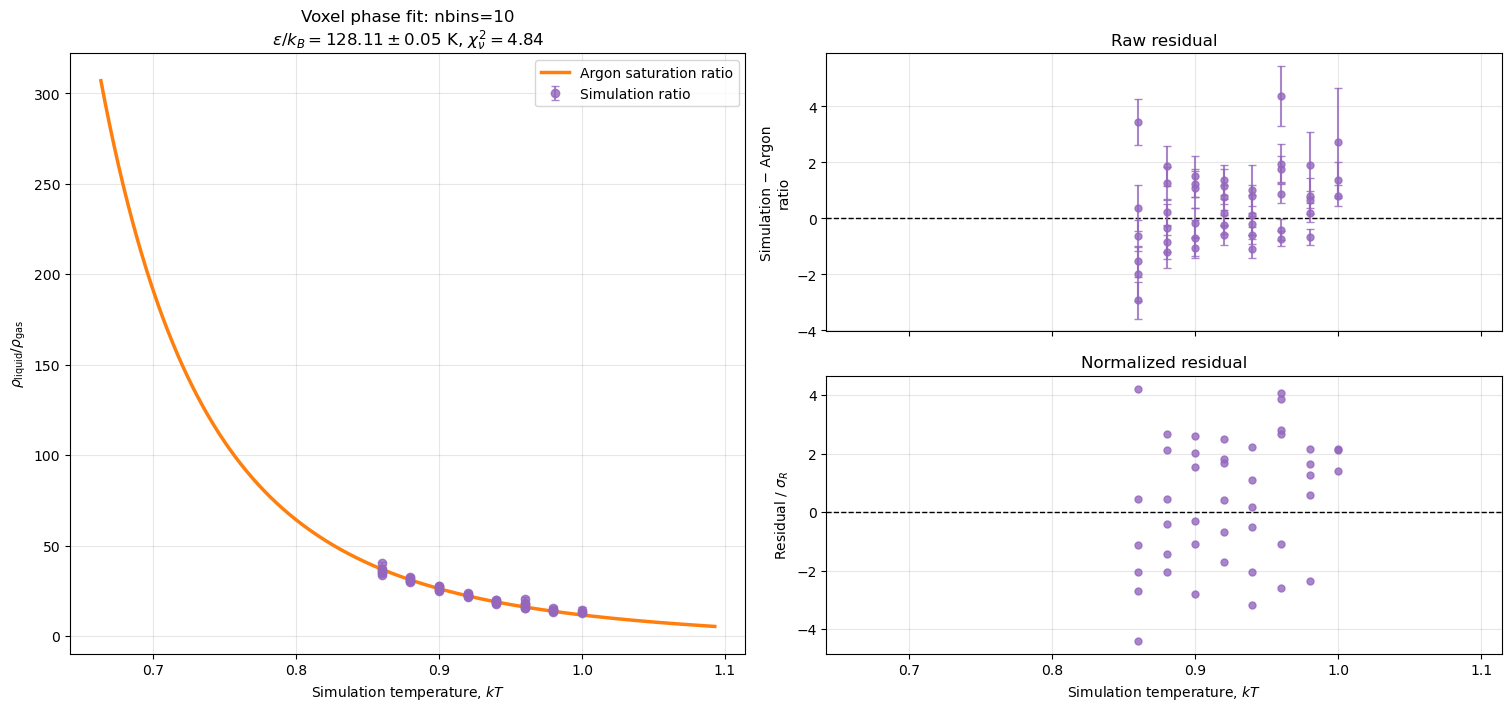

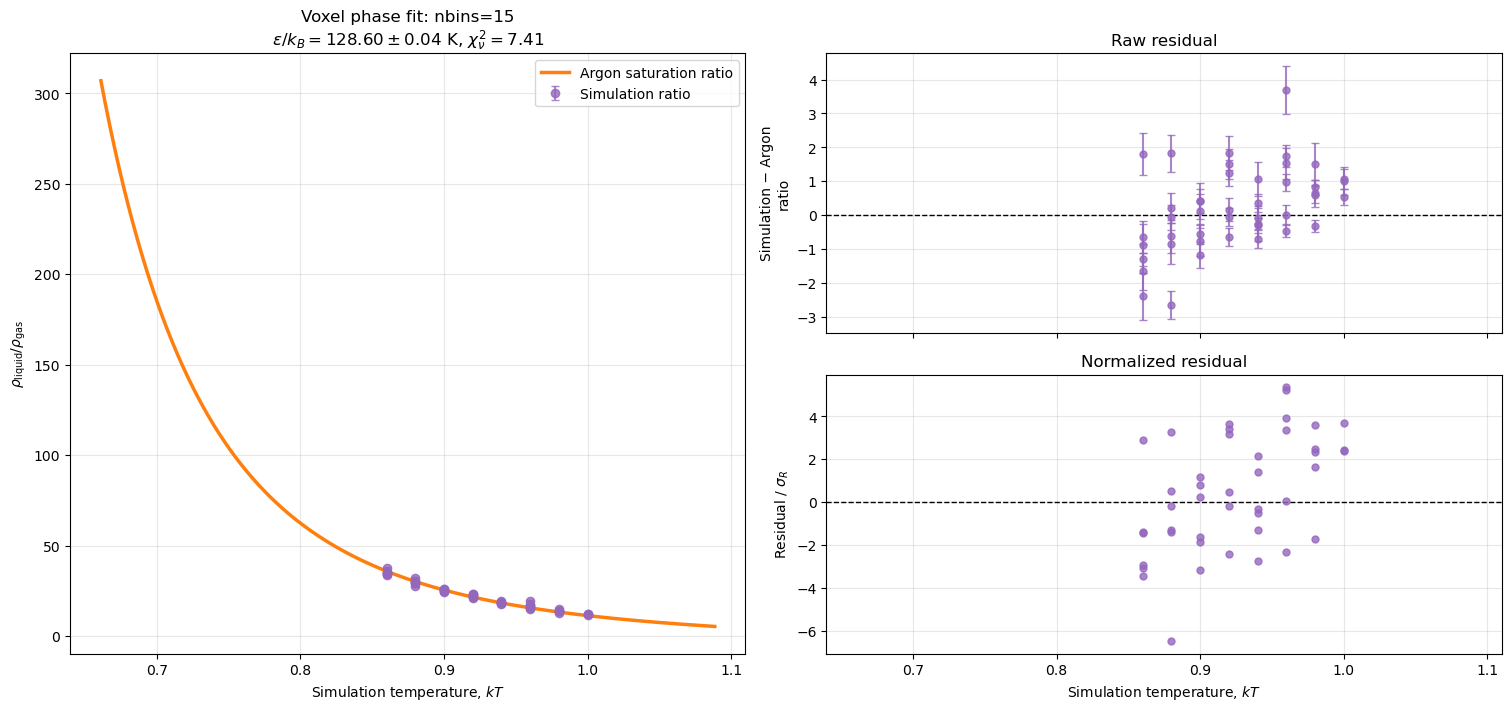

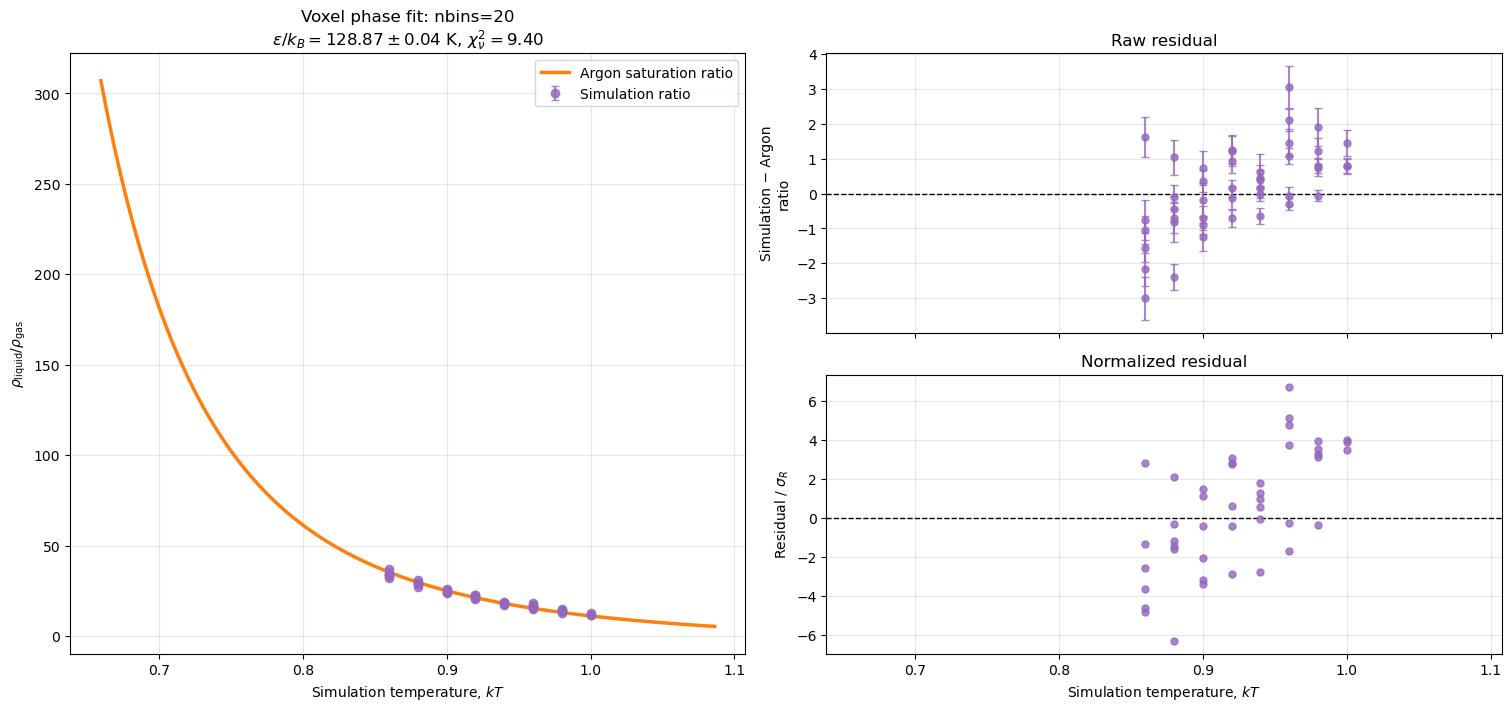

,nbins,states_fitted,epsilon_over_kB_K,epsilon_unc_K,chi_square,degrees_of_freedom,reduced_chi2
0,10,44,128.107312,0.054662,207.992782,43,4.837041
1,15,44,128.599551,0.042110,318.602948,43,7.409371
2,20,44,128.870668,0.039035,404.171440,43,9.399336


,nbins,Run_ID,Therm_kT,rho_liquid,rho_gas,rho_liquid_to_gas,ratio_unc,argon_ratio_at_fitted_T,raw_residual,weighted_residual
0,10,20260915173225,0.86,0.715722,0.019732,36.272150,0.551391,36.894742,-0.622593,-1.129131
1,10,20260915173427,0.86,0.716847,0.020272,35.361377,0.565747,36.894742,-1.533366,-2.710340
2,10,20260915173627,0.86,0.713157,0.020987,33.981611,0.660045,36.894742,-2.913131,-4.413535
3,10,20260915173827,0.86,0.713276,0.017686,40.330756,0.812732,36.894742,3.436014,4.227733
4,10,20260915174027,0.86,0.715334,0.019196,37.265046,0.809902,36.894742,0.370304,0.457221
...,...,...,...,...,...,...,...,...,...,...
39,20,20260915183740,0.98,0.621065,0.043614,14.239960,0.372441,13.018899,1.221061,3.278537
40,20,20260915183749,0.98,0.614831,0.041154,14.939671,0.542971,13.018899,1.920772,3.537525
41,20,20260915184126,1.0,0.604834,0.050931,11.875653,0.199840,11.075784,0.799869,4.002542
42,20,20260915184318,1.0,0.604732,0.050934,11.872841,0.228604,11.075784,0.797057,3.486631


In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from md_Helpers import (
    ProjectPaths,
    SQLiteRunDatabase,
    cavitations_with_nbins_fit,
    fit_argon_lj_scale,
    refit_cavitation_nbins,
    thermalization_dataframe,
)
from md_Helpers.argon_scaling import default_argon_saturation_path


# ============================================================
# Settings — change this list to try different voxel resolutions
# ============================================================

nbins_values = [10, 15, 20]


# ============================================================
# Database and thermalization-state selection
# ============================================================

paths = ProjectPaths()
database = SQLiteRunDatabase(paths.database)
database.initialize()

matches = thermalization_dataframe(
    database,
    N_Cells=40,
    Cumulative_LJ_Time=200,
    Phase_Separation_Status="Separated",
    rho_gas_unc=(None, 0.002),
    Therm_kT=(0.85, None),
    Clone_Run_ID=None,
)

if matches.empty:
    raise ValueError("The thermalization query returned no matching states.")

print(f"Selected {len(matches)} thermalization states.")
display(
    matches[
        [
            "Run_ID",
            "Therm_kT",
            "rho_liquid",
            "rho_gas",
            "rho_gas_unc",
        ]
    ]
)


# ============================================================
# Refit every selected trajectory for every requested nbins
#
# This is read-only. SQL, HDF5, and GSD files are not changed.
# ============================================================

trial_fits = refit_cavitation_nbins(
    matches,
    nbins_values=nbins_values,
    project_paths=paths,
)


# ============================================================
# Load the real Argon saturation curve
# ============================================================

argon_path = default_argon_saturation_path()

if not argon_path.exists():
    raise FileNotFoundError(f"Missing Argon table: {argon_path}")

argon = pd.read_csv(argon_path)

argon_T = pd.to_numeric(
    argon["temperature_K"],
    errors="coerce",
).to_numpy(dtype=float)

argon_ratio = (
    pd.to_numeric(
        argon["density_liquid_mol_L"],
        errors="coerce",
    )
    / pd.to_numeric(
        argon["density_vapor_mol_L"],
        errors="coerce",
    )
).to_numpy(dtype=float)

valid_argon = (
    np.isfinite(argon_T)
    & np.isfinite(argon_ratio)
    & (argon_ratio > 0)
)

argon_T = argon_T[valid_argon]
argon_ratio = argon_ratio[valid_argon]

order = np.argsort(argon_T)
argon_T = argon_T[order]
argon_ratio = argon_ratio[order]


# ============================================================
# Make one complete plot for each nbins
# ============================================================

comparison_records = []
phase_fit_results = {}

for nbins in nbins_values:

    # Substitute this nbins fit into a copy of the selected rows.
    trial_states = cavitations_with_nbins_fit(
        matches,
        trial_fits,
        nbins=nbins,
    )

    # Perform the Argon fit with these recalculated phase densities.
    argon_fit = fit_argon_lj_scale(
        trial_states,
        argon_table=argon,
        initial_temperature_scale_K=132,
    )

    scale_K = argon_fit.scale.epsilon_over_kb_K
    scale_unc_K = (
        argon_fit.scale.epsilon_over_kb_uncertainty_K
    )
    reduced_chi2 = argon_fit.temperature_reduced_chi2

    fit_data = argon_fit.ratio_data.copy()

    x = fit_data["Therm_kT"].to_numpy(dtype=float)
    y = fit_data["rho_liquid_to_gas"].to_numpy(dtype=float)
    y_unc = fit_data["ratio_unc"].to_numpy(dtype=float)

    predicted = fit_data["argon_ratio"].to_numpy(dtype=float)
    difference = y - predicted
    weighted_resid = difference / y_unc

    fit_data["argon_ratio_at_fitted_T"] = predicted
    fit_data["raw_residual"] = difference
    fit_data["weighted_residual"] = weighted_resid
    fit_data["voxel_nbins"] = nbins

    phase_fit_results[nbins] = fit_data

    comparison_records.append(
        {
            "nbins": nbins,
            "states_fitted": len(fit_data),
            "epsilon_over_kB_K": scale_K,
            "epsilon_unc_K": scale_unc_K,
            "chi_square": argon_fit.temperature_chi2,
            "degrees_of_freedom": argon_fit.temperature_dof,
            "reduced_chi2": reduced_chi2,
        }
    )

    # --------------------------------------------------------
    # Plot layout
    # --------------------------------------------------------

    figure = plt.figure(
        figsize=(15, 7),
        constrained_layout=True,
    )

    grid = figure.add_gridspec(
        2,
        2,
        width_ratios=[1, 1],
        height_ratios=[1, 1],
    )

    ax_ratio = figure.add_subplot(grid[:, 0])
    ax_diff = figure.add_subplot(
        grid[0, 1],
        sharex=ax_ratio,
    )
    ax_resid = figure.add_subplot(
        grid[1, 1],
        sharex=ax_ratio,
    )

    # --------------------------------------------------------
    # Left: simulation ratio and real Argon curve
    # --------------------------------------------------------

    ax_ratio.plot(
        argon_T / scale_K,
        argon_ratio,
        color="tab:orange",
        linewidth=2.5,
        label="Argon saturation ratio",
    )

    ax_ratio.errorbar(
        x,
        y,
        yerr=y_unc,
        fmt="o",
        linestyle="none",
        markersize=6,
        capsize=3,
        color="tab:purple",
        alpha=0.8,
        label="Simulation ratio",
    )

    ax_ratio.set_xlabel(
        r"Simulation temperature, $kT$"
    )
    ax_ratio.set_ylabel(
        r"$\rho_{\mathrm{liquid}}/"
        r"\rho_{\mathrm{gas}}$"
    )
    ax_ratio.set_title(
        f"Voxel phase fit: nbins={nbins}\n"
        rf"$\epsilon/k_B={scale_K:.2f}"
        rf"\pm{scale_unc_K:.2f}$ K, "
        rf"$\chi^2_\nu={reduced_chi2:.2f}$"
    )
    ax_ratio.grid(alpha=0.3)
    ax_ratio.legend()

    # --------------------------------------------------------
    # Upper right: raw residual
    # --------------------------------------------------------

    ax_diff.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1,
    )

    ax_diff.errorbar(
        x,
        difference,
        yerr=y_unc,
        fmt="o",
        linestyle="none",
        markersize=5,
        capsize=3,
        color="tab:purple",
        alpha=0.8,
    )

    ax_diff.set_title("Raw residual")
    ax_diff.set_ylabel(
        "Simulation − Argon\nratio"
    )
    ax_diff.grid(alpha=0.3)
    ax_diff.tick_params(
        axis="x",
        labelbottom=False,
    )

    # --------------------------------------------------------
    # Lower right: normalized residual
    # --------------------------------------------------------

    ax_resid.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1,
    )

    ax_resid.plot(
        x,
        weighted_resid,
        "o",
        markersize=5,
        color="tab:purple",
        alpha=0.8,
    )

    ax_resid.set_title("Normalized residual")
    ax_resid.set_xlabel(
        r"Simulation temperature, $kT$"
    )
    ax_resid.set_ylabel(
        r"Residual / $\sigma_R$"
    )
    ax_resid.grid(alpha=0.3)

    plt.show()


# ============================================================
# Compare the nbins choices numerically
# ============================================================

nbins_comparison = pd.DataFrame(
    comparison_records
).sort_values("nbins").reset_index(drop=True)

display(nbins_comparison)


# All point-level results in one table
all_phase_fit_data = pd.concat(
    phase_fit_results,
    names=["nbins"],
).reset_index(level=0)

display(
    all_phase_fit_data[
        [
            "nbins",
            "Run_ID",
            "Therm_kT",
            "rho_liquid",
            "rho_gas",
            "rho_liquid_to_gas",
            "ratio_unc",
            "argon_ratio_at_fitted_T",
            "raw_residual",
            "weighted_residual",
        ]
    ]
)

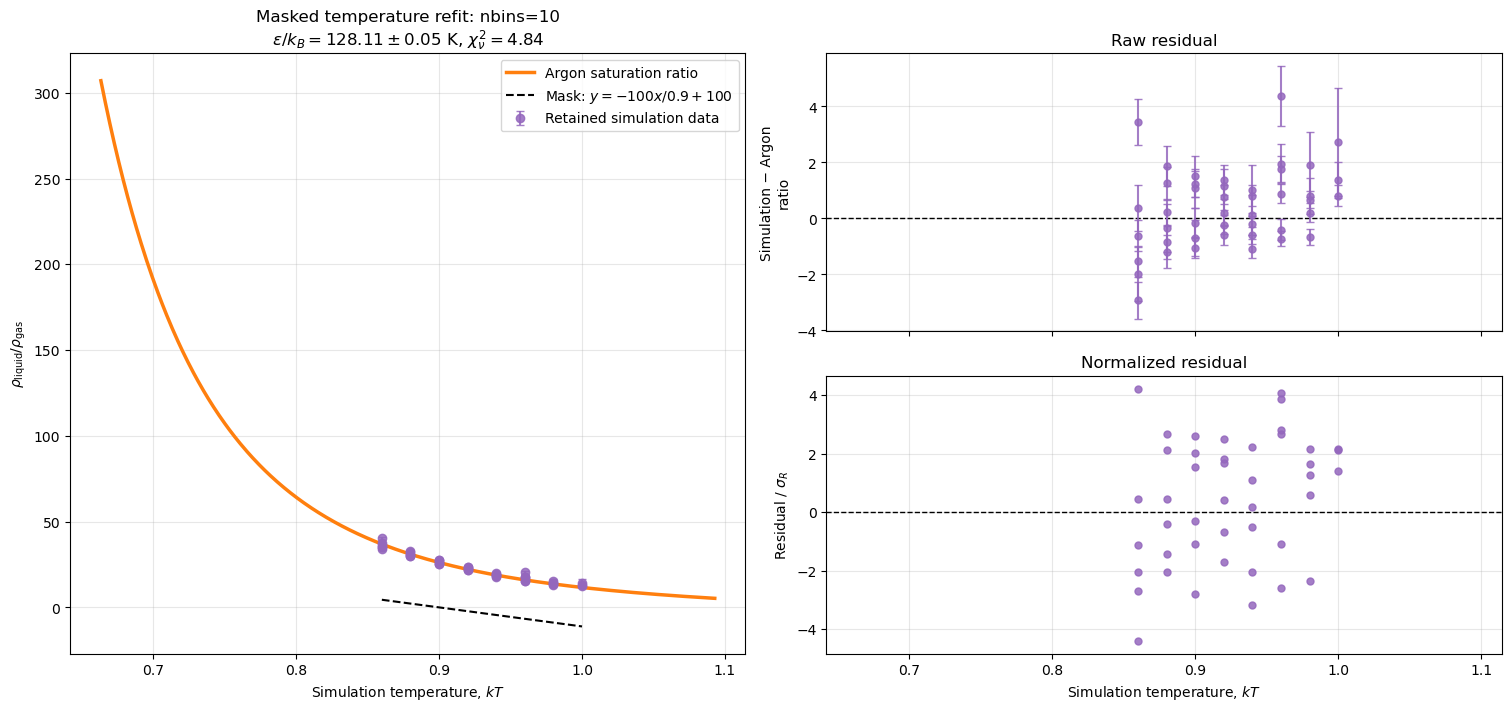

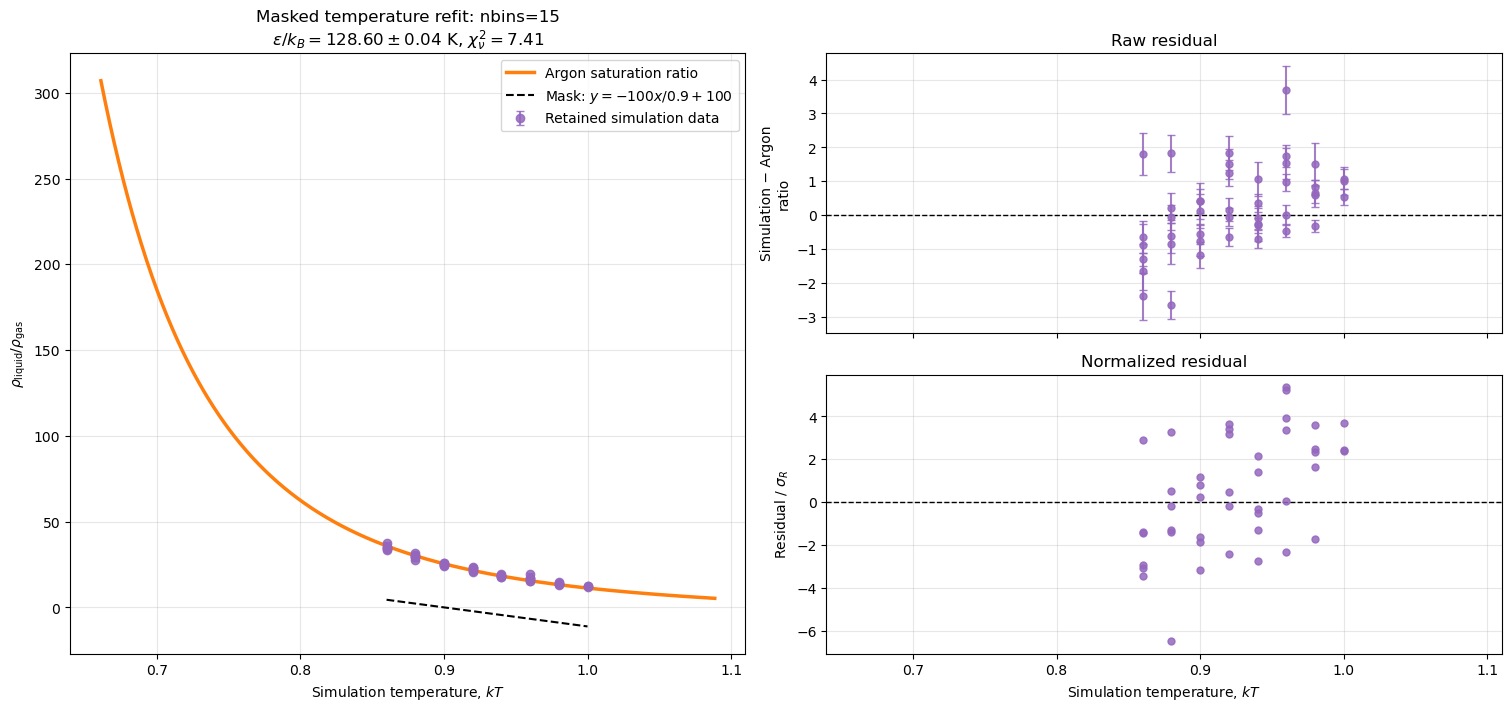

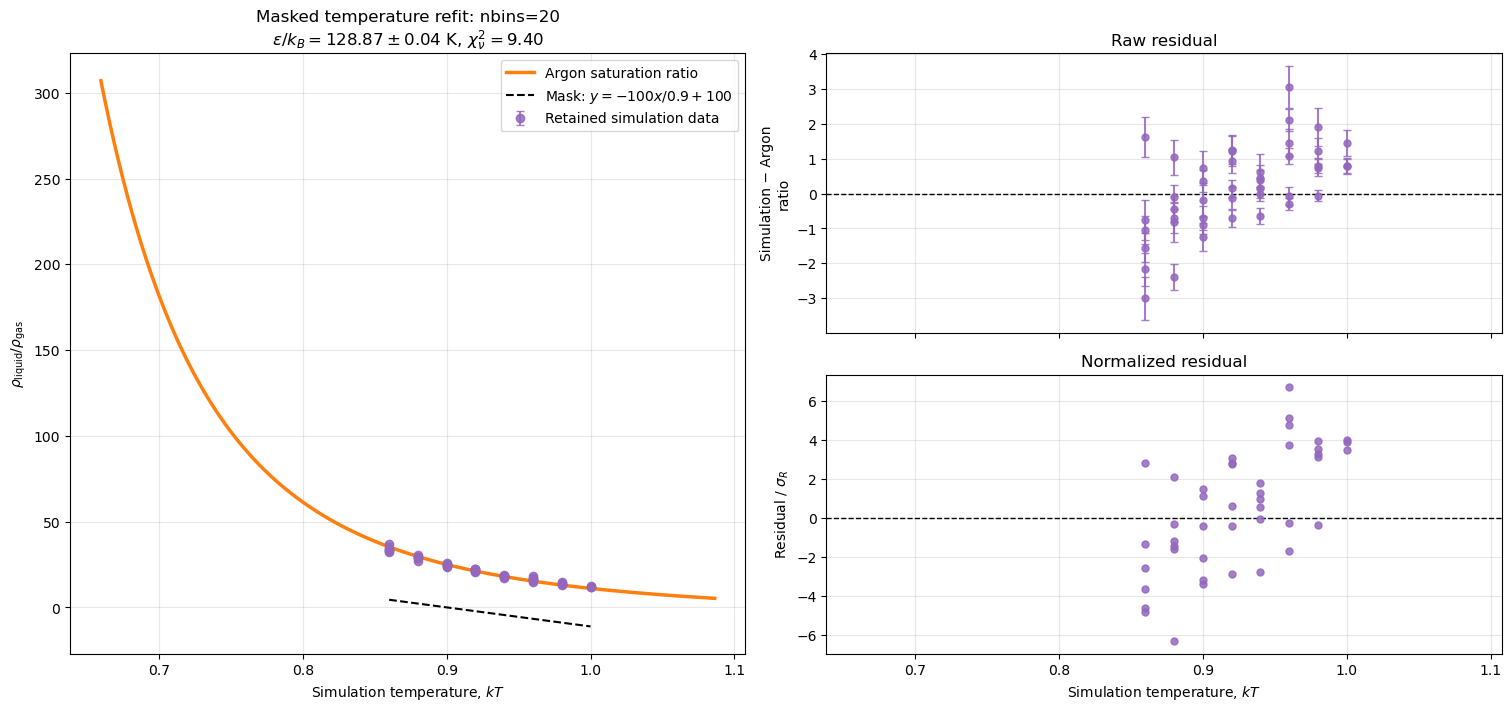

,nbins,points_before_mask,points_removed,points_fitted,epsilon_over_kB_K,epsilon_unc_K,chi_square,degrees_of_freedom,reduced_chi2
0,10,44,0,44,128.107312,0.054662,207.992782,43,4.837041
1,15,44,0,44,128.599551,0.042110,318.602948,43,7.409371
2,20,44,0,44,128.870668,0.039035,404.171440,43,9.399336


ValueError: cannot insert nbins, already exists

In [5]:
from scipy.optimize import least_squares


# ============================================================
# Mask and temperature-rescaling settings
# ============================================================

initial_scale_K = 132.0

# Keep points on or above:
# ratio = -(100 / 0.9) * kT + 100
def mask_line(kT):
    return -(100 / 0.9) * kT + 100


# ============================================================
# Refit the temperature scale for each existing nbins result
# ============================================================

masked_comparison_records = []
masked_phase_fit_results = {}

for nbins in sorted(
    all_phase_fit_data["nbins"].unique()
):
    original_data = all_phase_fit_data.loc[
        all_phase_fit_data["nbins"] == nbins
    ].copy()

    required_columns = [
        "Therm_kT",
        "rho_liquid_to_gas",
        "ratio_unc",
    ]

    for column in required_columns:
        original_data[column] = pd.to_numeric(
            original_data[column],
            errors="coerce",
        )

    original_data = original_data.dropna(
        subset=required_columns
    )

    original_data = original_data.loc[
        (original_data["Therm_kT"] > 0)
        & (original_data["rho_liquid_to_gas"] > 0)
        & (original_data["ratio_unc"] > 0)
    ].copy()

    # --------------------------------------------------------
    # Apply the mask
    # --------------------------------------------------------

    boundary = mask_line(
        original_data["Therm_kT"]
    )

    keep_mask = (
        original_data["rho_liquid_to_gas"]
        >= boundary
    )

    fit_data = original_data.loc[
        keep_mask
    ].copy()

    removed_data = original_data.loc[
        ~keep_mask
    ].copy()

    if len(fit_data) < 3:
        print(
            f"Skipping nbins={nbins}: only "
            f"{len(fit_data)} points remain after masking."
        )
        continue

    x = fit_data[
        "Therm_kT"
    ].to_numpy(dtype=float)

    y = fit_data[
        "rho_liquid_to_gas"
    ].to_numpy(dtype=float)

    y_unc = fit_data[
        "ratio_unc"
    ].to_numpy(dtype=float)

    # --------------------------------------------------------
    # Bounds that keep every fitted point inside the Argon table
    # --------------------------------------------------------

    scale_lower = argon_T.min() / x.min()
    scale_upper = argon_T.max() / x.max()

    if scale_lower >= scale_upper:
        print(
            f"Skipping nbins={nbins}: the retained points "
            "cannot share one Argon temperature scale."
        )
        continue

    # --------------------------------------------------------
    # One-parameter weighted temperature-rescaling refit
    # --------------------------------------------------------

    def weighted_residual(parameters):
        trial_scale_K = parameters[0]

        predicted_ratio = np.interp(
            trial_scale_K * x,
            argon_T,
            argon_ratio,
        )

        return (
            y - predicted_ratio
        ) / y_unc

    temperature_fit = least_squares(
        weighted_residual,
        x0=[
            np.clip(
                initial_scale_K,
                scale_lower,
                scale_upper,
            )
        ],
        bounds=(
            [scale_lower],
            [scale_upper],
        ),
    )

    if not temperature_fit.success:
        print(
            f"Skipping nbins={nbins}: "
            f"{temperature_fit.message}"
        )
        continue

    # --------------------------------------------------------
    # Fit results
    # --------------------------------------------------------

    scale_K = float(
        temperature_fit.x[0]
    )

    predicted = np.interp(
        scale_K * x,
        argon_T,
        argon_ratio,
    )

    difference = y - predicted
    weighted_resid = difference / y_unc

    chi2 = float(
        np.sum(weighted_resid**2)
    )

    dof = len(x) - 1
    reduced_chi2 = chi2 / dof

    jacobian = temperature_fit.jac[:, 0]

    scale_unc_K = (
        1 / np.sqrt(np.sum(jacobian**2))
        if np.sum(jacobian**2) > 0
        else np.nan
    )

    fit_data["argon_ratio_at_fitted_T"] = predicted
    fit_data["raw_residual"] = difference
    fit_data["weighted_residual"] = weighted_resid
    fit_data["masked_temperature_scale_K"] = scale_K

    masked_phase_fit_results[nbins] = fit_data

    masked_comparison_records.append(
        {
            "nbins": nbins,
            "points_before_mask": len(original_data),
            "points_removed": len(removed_data),
            "points_fitted": len(fit_data),
            "epsilon_over_kB_K": scale_K,
            "epsilon_unc_K": scale_unc_K,
            "chi_square": chi2,
            "degrees_of_freedom": dof,
            "reduced_chi2": reduced_chi2,
        }
    )

    # ========================================================
    # Plot
    # ========================================================

    figure = plt.figure(
        figsize=(15, 7),
        constrained_layout=True,
    )

    grid = figure.add_gridspec(
        2,
        2,
        width_ratios=[1, 1],
        height_ratios=[1, 1],
    )

    ax_ratio = figure.add_subplot(
        grid[:, 0]
    )

    ax_diff = figure.add_subplot(
        grid[0, 1],
        sharex=ax_ratio,
    )

    ax_resid = figure.add_subplot(
        grid[1, 1],
        sharex=ax_ratio,
    )

    # --------------------------------------------------------
    # Left: retained data and refitted Argon curve
    # --------------------------------------------------------

    ax_ratio.plot(
        argon_T / scale_K,
        argon_ratio,
        color="tab:orange",
        linewidth=2.5,
        label="Argon saturation ratio",
    )

    ax_ratio.errorbar(
        x,
        y,
        yerr=y_unc,
        fmt="o",
        linestyle="none",
        markersize=6,
        capsize=3,
        color="tab:purple",
        alpha=0.85,
        label="Retained simulation data",
    )

    # Show removed points for reference.
    if not removed_data.empty:
        ax_ratio.plot(
            removed_data["Therm_kT"],
            removed_data["rho_liquid_to_gas"],
            "x",
            color="tab:red",
            markersize=8,
            markeredgewidth=2,
            label="Removed by mask",
        )

    # Draw the masking line.
    mask_x = np.linspace(
        original_data["Therm_kT"].min(),
        original_data["Therm_kT"].max(),
        300,
    )

    ax_ratio.plot(
        mask_x,
        mask_line(mask_x),
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=r"Mask: $y=-100x/0.9+100$",
    )

    ax_ratio.set_xlabel(
        r"Simulation temperature, $kT$"
    )

    ax_ratio.set_ylabel(
        r"$\rho_{\mathrm{liquid}}/"
        r"\rho_{\mathrm{gas}}$"
    )

    ax_ratio.set_title(
        f"Masked temperature refit: nbins={nbins}\n"
        rf"$\epsilon/k_B={scale_K:.2f}"
        rf"\pm{scale_unc_K:.2f}$ K, "
        rf"$\chi^2_\nu={reduced_chi2:.2f}$"
    )

    ax_ratio.grid(alpha=0.3)
    ax_ratio.legend()

    # --------------------------------------------------------
    # Upper right: raw residual
    # --------------------------------------------------------

    ax_diff.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1,
    )

    ax_diff.errorbar(
        x,
        difference,
        yerr=y_unc,
        fmt="o",
        linestyle="none",
        markersize=5,
        capsize=3,
        color="tab:purple",
        alpha=0.85,
    )

    ax_diff.set_title("Raw residual")
    ax_diff.set_ylabel(
        "Simulation − Argon\nratio"
    )
    ax_diff.grid(alpha=0.3)
    ax_diff.tick_params(
        axis="x",
        labelbottom=False,
    )

    # --------------------------------------------------------
    # Lower right: normalized residual
    # --------------------------------------------------------

    ax_resid.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1,
    )

    ax_resid.plot(
        x,
        weighted_resid,
        "o",
        markersize=5,
        color="tab:purple",
        alpha=0.85,
    )

    ax_resid.set_title(
        "Normalized residual"
    )

    ax_resid.set_xlabel(
        r"Simulation temperature, $kT$"
    )

    ax_resid.set_ylabel(
        r"Residual / $\sigma_R$"
    )

    ax_resid.grid(alpha=0.3)

    plt.show()


# ============================================================
# Compare masked refits
# ============================================================

masked_nbins_comparison = pd.DataFrame(
    masked_comparison_records
).sort_values(
    "nbins"
).reset_index(drop=True)

display(masked_nbins_comparison)


# Combined point-level results after masking
masked_phase_data = pd.concat(
    masked_phase_fit_results,
    names=["nbins"],
).reset_index(level=0)

display(
    masked_phase_data[
        [
            "nbins",
            "Run_ID",
            "Therm_kT",
            "rho_liquid_to_gas",
            "ratio_unc",
            "argon_ratio_at_fitted_T",
            "raw_residual",
            "weighted_residual",
        ]
    ]
)

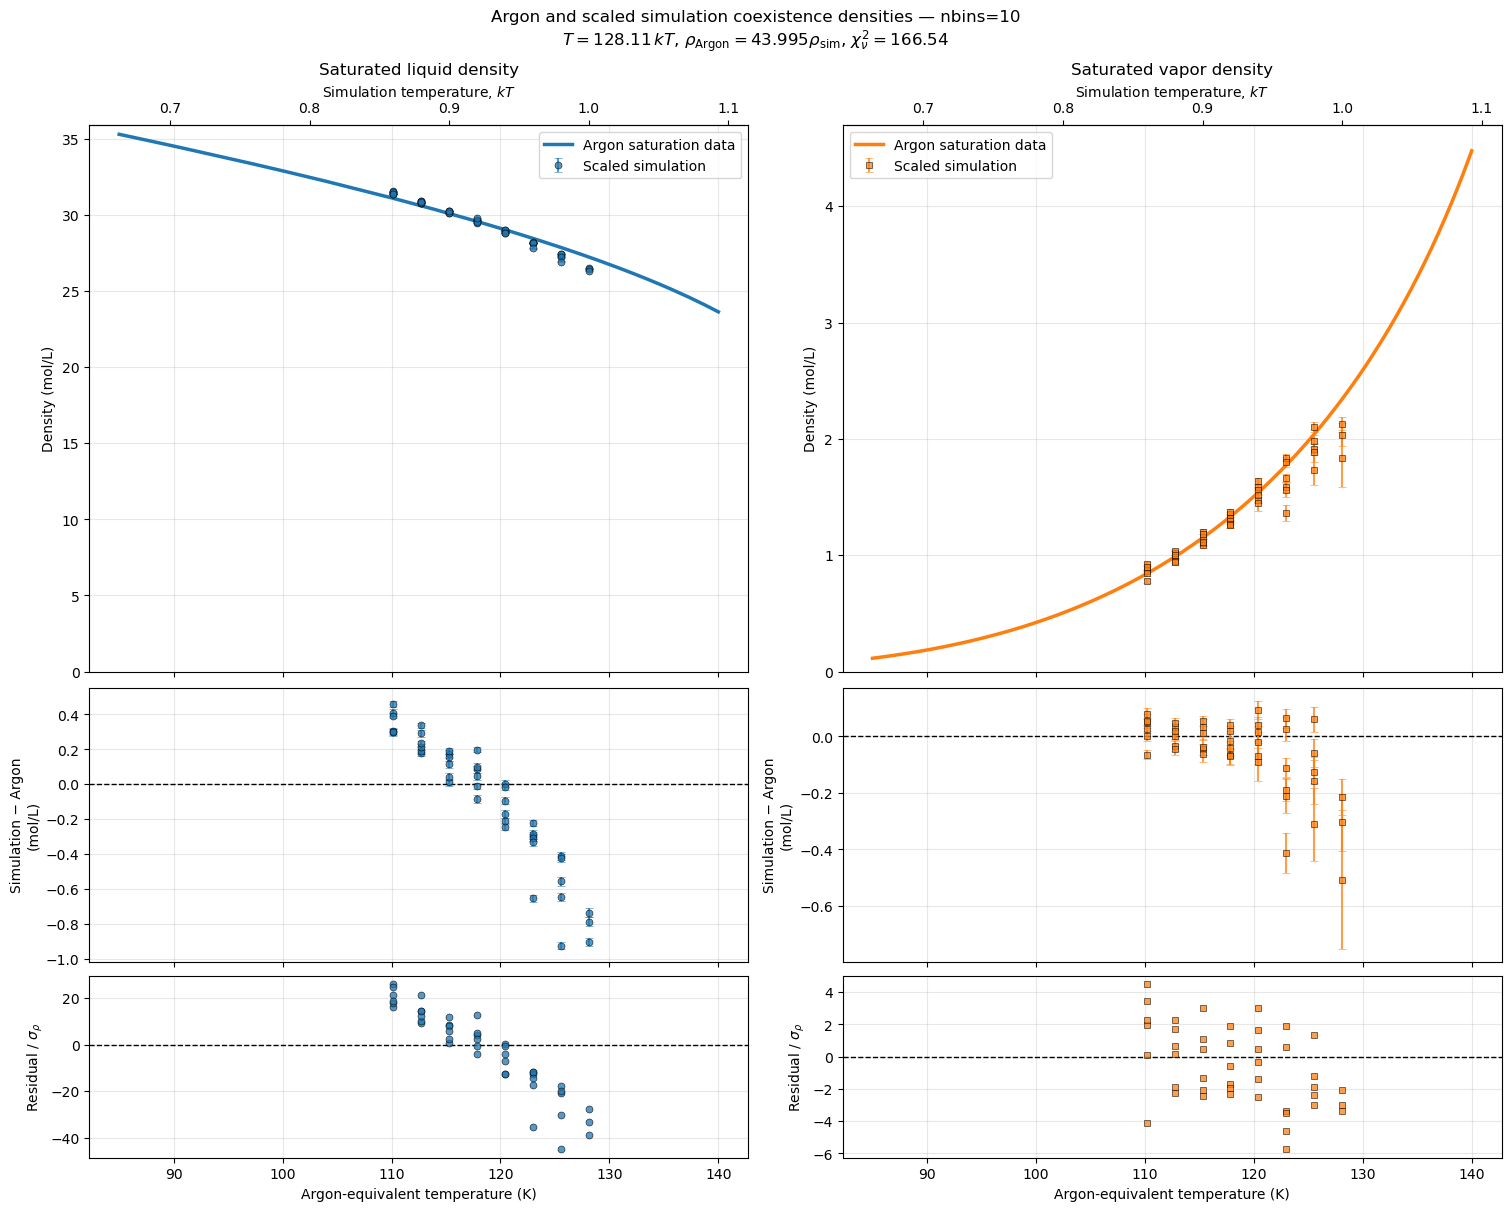

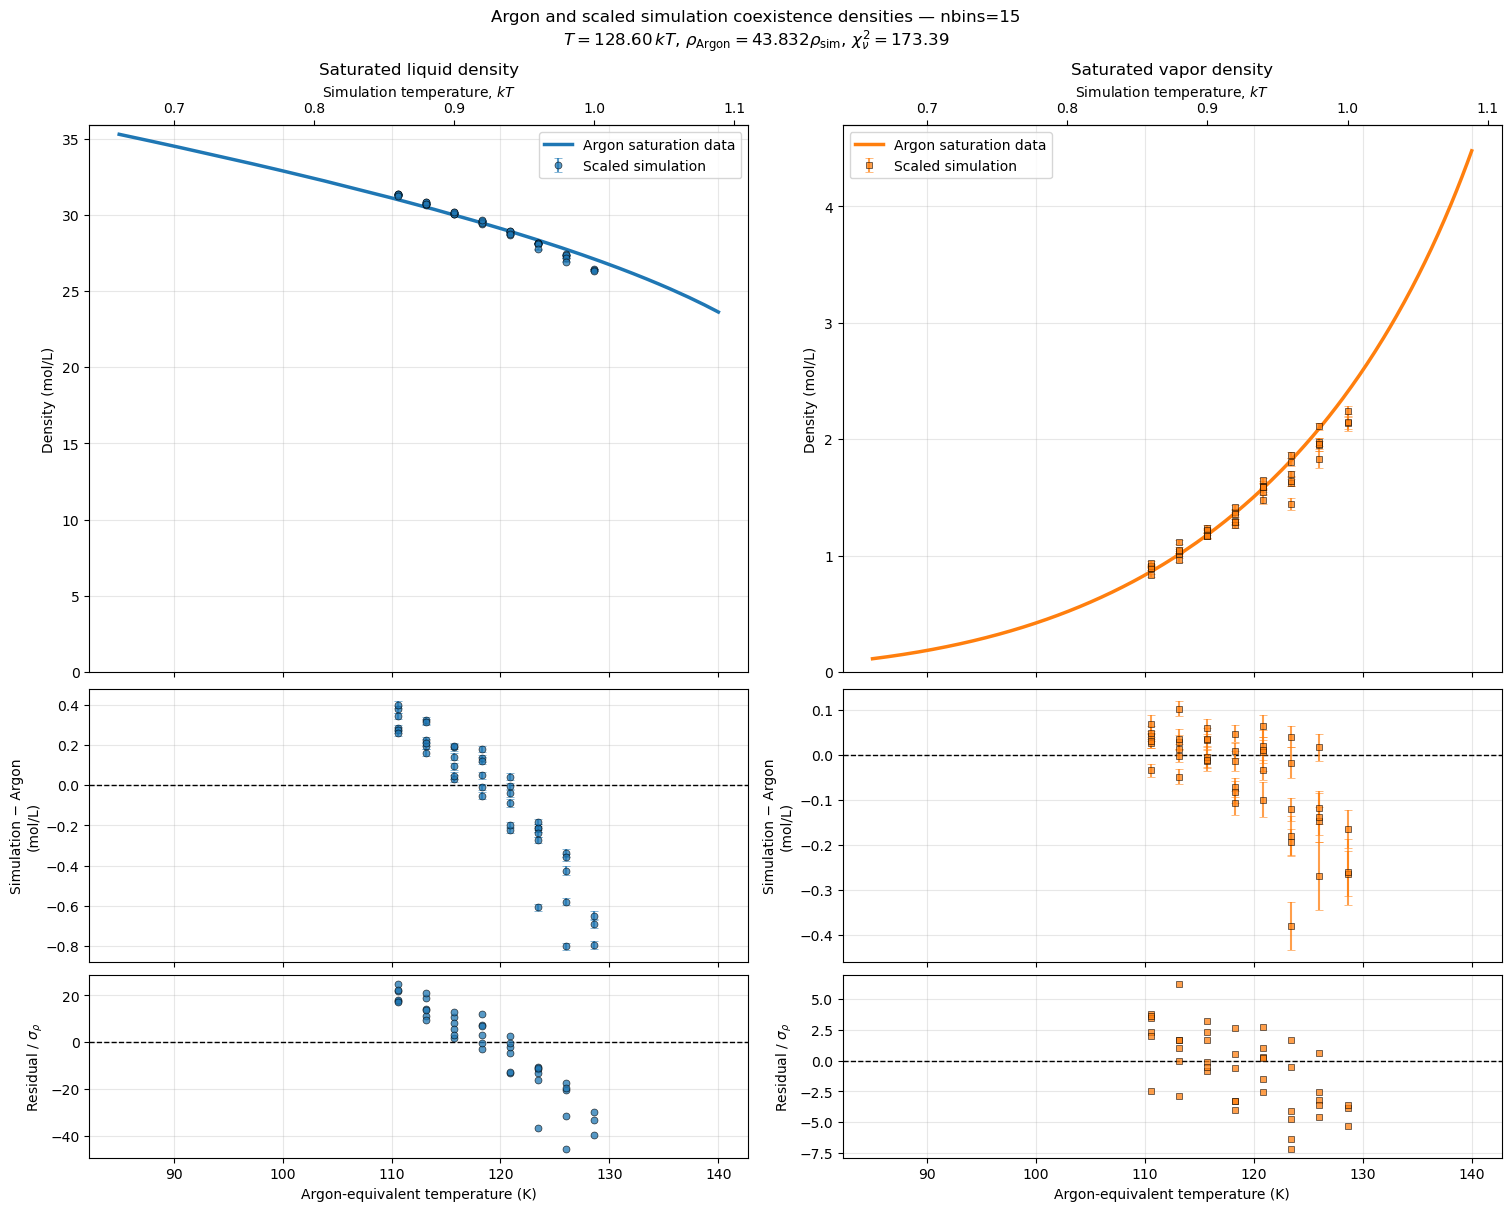

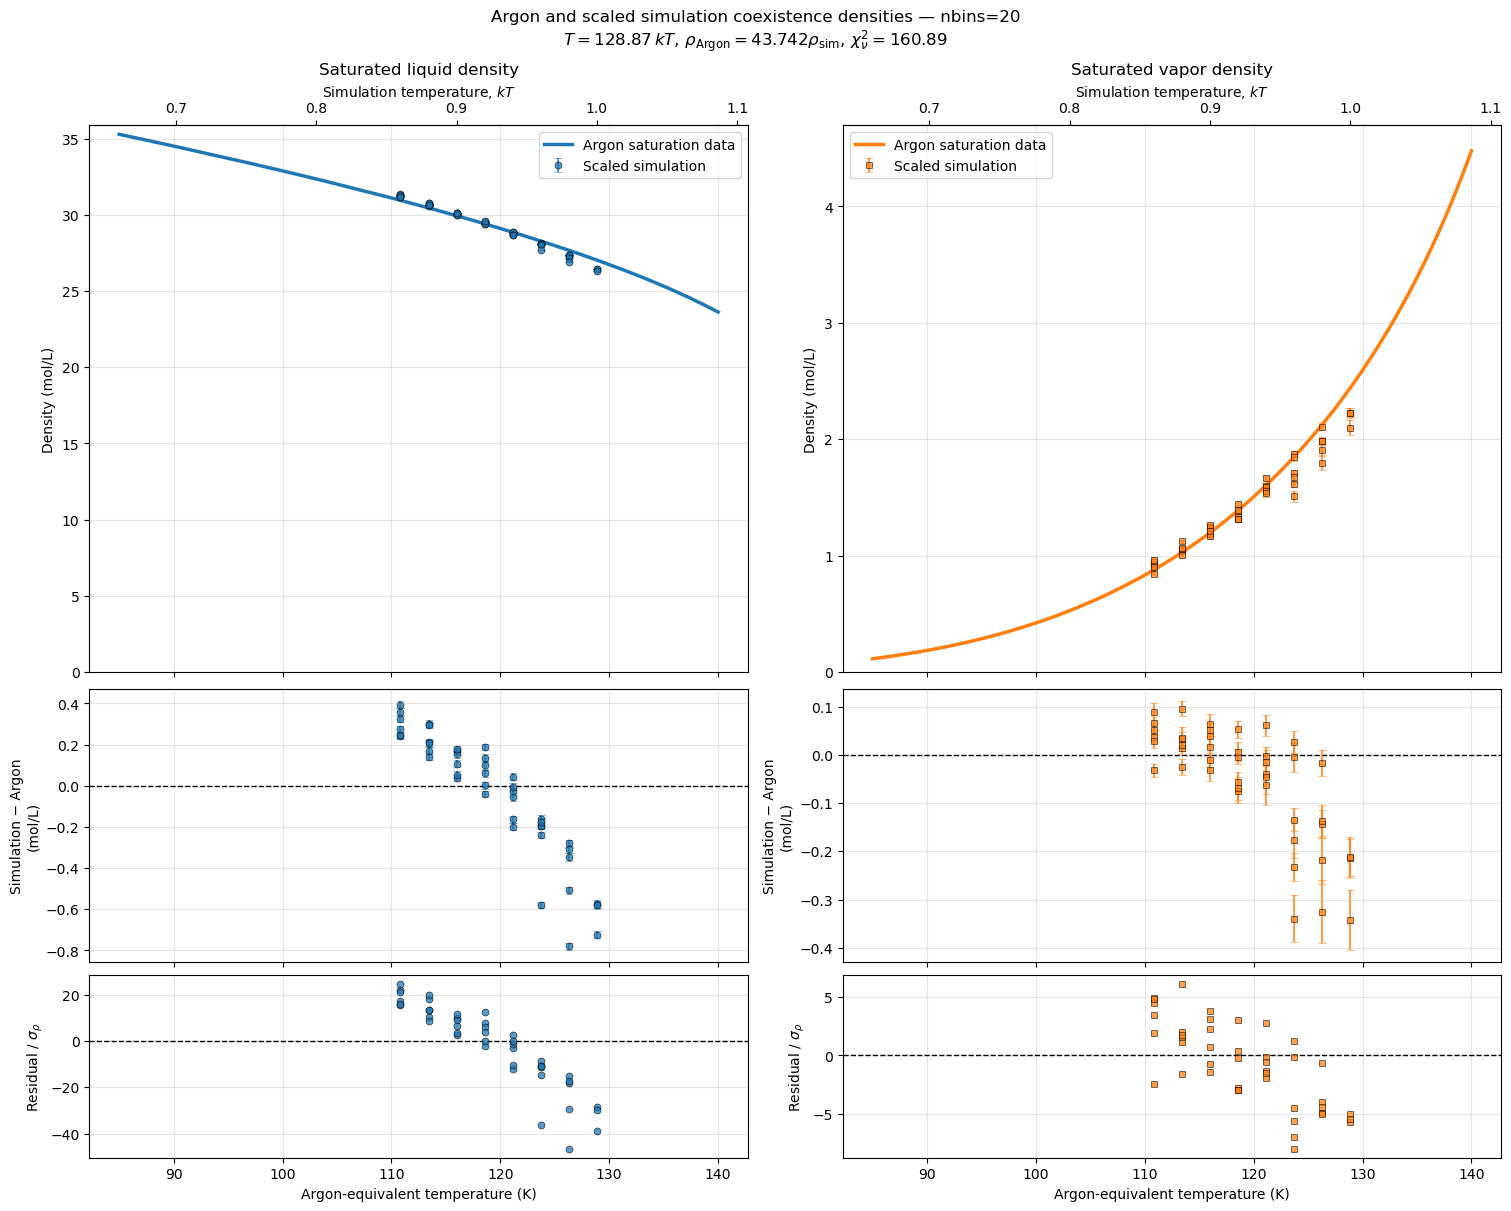

,nbins,points,temperature_scale_K,temperature_scale_unc_K,density_scale_mol_L,density_scale_unc_mol_L,sigma_nm,sigma_unc_nm,density_chi2,density_dof,density_reduced_chi2
0,10,44,128.107312,0.054662,43.994515,0.004315,0.335442,0.000011,14488.665508,87,166.536385
1,15,44,128.599551,0.042110,43.832354,0.003817,0.335855,0.000010,15085.190099,87,173.392990
2,20,44,128.870668,0.039035,43.741623,0.003731,0.336087,0.000010,13997.336277,87,160.888923


ValueError: cannot insert nbins, already exists

In [6]:
# ============================================================
# Recreate the coexistence-density plot for every masked nbins
#
# Requires these variables from the preceding cells:
#   masked_phase_fit_results
#   masked_nbins_comparison
#   argon
#
# No voxel fits or temperature fits are repeated here.
# ============================================================

density_scale_records = []
density_plot_results = {}


# Prepare the Argon liquid and vapor curves once.
argon_density = argon[
    [
        "temperature_K",
        "density_liquid_mol_L",
        "density_vapor_mol_L",
    ]
].copy()

argon_density = (
    argon_density
    .apply(pd.to_numeric, errors="coerce")
    .dropna()
    .sort_values("temperature_K")
    .drop_duplicates("temperature_K")
    .reset_index(drop=True)
)

argon_temperature = argon_density[
    "temperature_K"
].to_numpy(dtype=float)

argon_liquid = argon_density[
    "density_liquid_mol_L"
].to_numpy(dtype=float)

argon_vapor = argon_density[
    "density_vapor_mol_L"
].to_numpy(dtype=float)


for nbins in sorted(masked_phase_fit_results):

    # ========================================================
    # Get the masked data and previously fitted temperature scale
    # ========================================================

    density_data = masked_phase_fit_results[
        nbins
    ][
        [
            "Run_ID",
            "Therm_kT",
            "rho_liquid",
            "rho_liquid_unc",
            "rho_gas",
            "rho_gas_unc",
        ]
    ].copy()

    scale_row = masked_nbins_comparison.loc[
        masked_nbins_comparison["nbins"] == nbins
    ]

    if scale_row.empty:
        print(
            f"Skipping nbins={nbins}: no masked "
            "temperature-scale result was found."
        )
        continue

    scale_K = float(
        scale_row.iloc[0]["epsilon_over_kB_K"]
    )

    scale_unc_K = float(
        scale_row.iloc[0]["epsilon_unc_K"]
    )

    numeric_columns = [
        "Therm_kT",
        "rho_liquid",
        "rho_liquid_unc",
        "rho_gas",
        "rho_gas_unc",
    ]

    for column in numeric_columns:
        density_data[column] = pd.to_numeric(
            density_data[column],
            errors="coerce",
        )

    density_data = density_data.dropna(
        subset=numeric_columns
    ).copy()

    density_data = density_data.loc[
        (density_data["Therm_kT"] > 0)
        & (density_data["rho_liquid"] > 0)
        & (density_data["rho_gas"] > 0)
        & (density_data["rho_liquid_unc"] > 0)
        & (density_data["rho_gas_unc"] > 0)
    ].copy()

    # Use the already-fitted temperature rescaling.
    density_data["temperature_K"] = (
        scale_K * density_data["Therm_kT"]
    )

    # Keep temperatures covered by the Argon table.
    density_data = density_data.loc[
        density_data["temperature_K"].between(
            argon_temperature.min(),
            argon_temperature.max(),
        )
    ].copy()

    if density_data.empty:
        print(
            f"Skipping nbins={nbins}: no retained points "
            "fall inside the Argon temperature range."
        )
        continue

    # Argon densities at the corresponding temperatures.
    density_data["argon_liquid_mol_L"] = np.interp(
        density_data["temperature_K"],
        argon_temperature,
        argon_liquid,
    )

    density_data["argon_vapor_mol_L"] = np.interp(
        density_data["temperature_K"],
        argon_temperature,
        argon_vapor,
    )

    # ========================================================
    # Fit one common density multiplier
    #
    # rho_Argon [mol/L] = density_scale * rho_sim
    # ========================================================

    liquid_points = pd.DataFrame(
        {
            "phase": "Liquid",
            "rho_sim": density_data["rho_liquid"],
            "rho_sim_unc": density_data["rho_liquid_unc"],
            "rho_argon": density_data["argon_liquid_mol_L"],
        }
    )

    vapor_points = pd.DataFrame(
        {
            "phase": "Vapor",
            "rho_sim": density_data["rho_gas"],
            "rho_sim_unc": density_data["rho_gas_unc"],
            "rho_argon": density_data["argon_vapor_mol_L"],
        }
    )

    density_fit_points = pd.concat(
        [liquid_points, vapor_points],
        ignore_index=True,
    )

    density_fit_points["relative_unc"] = (
        density_fit_points["rho_sim_unc"]
        / density_fit_points["rho_sim"]
    )

    density_fit_points["log_scale_needed"] = np.log(
        density_fit_points["rho_argon"]
        / density_fit_points["rho_sim"]
    )

    density_fit_points["weight"] = (
        1.0
        / density_fit_points["relative_unc"] ** 2
    )

    log_density_scale = np.average(
        density_fit_points["log_scale_needed"],
        weights=density_fit_points["weight"],
    )

    density_scale = float(
        np.exp(log_density_scale)
    )

    log_density_scale_unc = float(
        1.0
        / np.sqrt(
            density_fit_points["weight"].sum()
        )
    )

    density_scale_unc = (
        density_scale
        * log_density_scale_unc
    )

    density_fit_points["weighted_log_residual"] = (
        np.log(
            density_scale
            * density_fit_points["rho_sim"]
            / density_fit_points["rho_argon"]
        )
        / density_fit_points["relative_unc"]
    )

    density_chi2 = float(
        np.sum(
            density_fit_points[
                "weighted_log_residual"
            ] ** 2
        )
    )

    density_dof = (
        len(density_fit_points) - 1
    )

    density_reduced_chi2 = (
        density_chi2 / density_dof
    )

    # ========================================================
    # Corresponding LJ sigma
    # ========================================================

    sigma_nm = (
        1.0
        / (0.602214076 * density_scale)
    ) ** (1.0 / 3.0)

    sigma_unc_nm = (
        sigma_nm
        * density_scale_unc
        / (3.0 * density_scale)
    )

    # ========================================================
    # Scale simulation densities
    # ========================================================

    density_data["rho_liquid_scaled_mol_L"] = (
        density_scale
        * density_data["rho_liquid"]
    )

    density_data["rho_liquid_scaled_unc_mol_L"] = (
        density_scale
        * density_data["rho_liquid_unc"]
    )

    density_data["rho_vapor_scaled_mol_L"] = (
        density_scale
        * density_data["rho_gas"]
    )

    density_data["rho_vapor_scaled_unc_mol_L"] = (
        density_scale
        * density_data["rho_gas_unc"]
    )

    # ========================================================
    # Raw residuals
    # ========================================================

    density_data["liquid_residual_mol_L"] = (
        density_data["rho_liquid_scaled_mol_L"]
        - density_data["argon_liquid_mol_L"]
    )

    density_data["vapor_residual_mol_L"] = (
        density_data["rho_vapor_scaled_mol_L"]
        - density_data["argon_vapor_mol_L"]
    )

    # ========================================================
    # Normalized residuals
    # ========================================================

    density_data["liquid_z_score"] = (
        density_data["liquid_residual_mol_L"]
        / density_data[
            "rho_liquid_scaled_unc_mol_L"
        ]
    )

    density_data["vapor_z_score"] = (
        density_data["vapor_residual_mol_L"]
        / density_data[
            "rho_vapor_scaled_unc_mol_L"
        ]
    )

    density_data = density_data.sort_values(
        ["temperature_K", "Run_ID"]
    ).reset_index(drop=True)

    density_data["nbins"] = nbins
    density_plot_results[nbins] = density_data

    density_scale_records.append(
        {
            "nbins": nbins,
            "points": len(density_data),
            "temperature_scale_K": scale_K,
            "temperature_scale_unc_K": scale_unc_K,
            "density_scale_mol_L": density_scale,
            "density_scale_unc_mol_L": (
                density_scale_unc
            ),
            "sigma_nm": sigma_nm,
            "sigma_unc_nm": sigma_unc_nm,
            "density_chi2": density_chi2,
            "density_dof": density_dof,
            "density_reduced_chi2": (
                density_reduced_chi2
            ),
        }
    )

    # ========================================================
    # Plot: liquid on left, vapor on right
    # ========================================================

    figure, axes = plt.subplots(
        3,
        2,
        figsize=(15, 12),
        sharex="col",
        gridspec_kw={
            "height_ratios": [3.0, 1.5, 1.0],
        },
        constrained_layout=True,
    )

    phase_plot_settings = [
        {
            "column": 0,
            "name": "Liquid",
            "color": "tab:blue",
            "marker": "o",
            "argon_curve": argon_liquid,
            "sim_density": (
                "rho_liquid_scaled_mol_L"
            ),
            "sim_unc": (
                "rho_liquid_scaled_unc_mol_L"
            ),
            "residual": (
                "liquid_residual_mol_L"
            ),
            "z_score": "liquid_z_score",
        },
        {
            "column": 1,
            "name": "Vapor",
            "color": "tab:orange",
            "marker": "s",
            "argon_curve": argon_vapor,
            "sim_density": (
                "rho_vapor_scaled_mol_L"
            ),
            "sim_unc": (
                "rho_vapor_scaled_unc_mol_L"
            ),
            "residual": (
                "vapor_residual_mol_L"
            ),
            "z_score": "vapor_z_score",
        },
    ]

    for settings in phase_plot_settings:
        column = settings["column"]

        ax_density = axes[0, column]
        ax_residual = axes[1, column]
        ax_z_score = axes[2, column]

        temperature_K = density_data[
            "temperature_K"
        ].to_numpy(dtype=float)

        sim_density = density_data[
            settings["sim_density"]
        ].to_numpy(dtype=float)

        sim_unc = density_data[
            settings["sim_unc"]
        ].to_numpy(dtype=float)

        residual = density_data[
            settings["residual"]
        ].to_numpy(dtype=float)

        z_score = density_data[
            settings["z_score"]
        ].to_numpy(dtype=float)

        # ----------------------------------------------------
        # Density comparison
        # ----------------------------------------------------

        ax_density.plot(
            argon_temperature,
            settings["argon_curve"],
            color=settings["color"],
            linewidth=2.5,
            label="Argon saturation data",
        )

        ax_density.errorbar(
            temperature_K,
            sim_density,
            yerr=sim_unc,
            fmt=settings["marker"],
            linestyle="none",
            markersize=5,
            capsize=3,
            color=settings["color"],
            markeredgecolor="black",
            markeredgewidth=0.5,
            alpha=0.75,
            label="Scaled simulation",
        )

        ax_density.set_title(
            f"Saturated "
            f"{settings['name'].lower()} density"
        )

        ax_density.set_ylabel(
            "Density (mol/L)"
        )

        ax_density.set_ylim(bottom=0)
        ax_density.grid(alpha=0.3)
        ax_density.legend()

        # Original simulation kT along the top.
        secondary_axis = (
            ax_density.secondary_xaxis(
                "top",
                functions=(
                    lambda temperature, s=scale_K: (
                        temperature / s
                    ),
                    lambda reduced_kT, s=scale_K: (
                        reduced_kT * s
                    ),
                ),
            )
        )

        secondary_axis.set_xlabel(
            r"Simulation temperature, $kT$"
        )

        # ----------------------------------------------------
        # Raw residual
        # ----------------------------------------------------

        ax_residual.axhline(
            0,
            color="black",
            linestyle="--",
            linewidth=1,
        )

        ax_residual.errorbar(
            temperature_K,
            residual,
            yerr=sim_unc,
            fmt=settings["marker"],
            linestyle="none",
            markersize=5,
            capsize=3,
            color=settings["color"],
            markeredgecolor="black",
            markeredgewidth=0.5,
            alpha=0.75,
        )

        ax_residual.set_ylabel(
            "Simulation − Argon\n(mol/L)"
        )

        ax_residual.grid(alpha=0.3)

        # ----------------------------------------------------
        # Normalized residual
        # ----------------------------------------------------

        ax_z_score.axhline(
            0,
            color="black",
            linestyle="--",
            linewidth=1,
        )

        ax_z_score.plot(
            temperature_K,
            z_score,
            settings["marker"],
            markersize=5,
            color=settings["color"],
            markeredgecolor="black",
            markeredgewidth=0.5,
            alpha=0.75,
        )

        ax_z_score.set_xlabel(
            "Argon-equivalent temperature (K)"
        )

        ax_z_score.set_ylabel(
            r"Residual / $\sigma_\rho$"
        )

        ax_z_score.grid(alpha=0.3)

    figure.suptitle(
        f"Argon and scaled simulation "
        f"coexistence densities — nbins={nbins}\n"
        rf"$T={scale_K:.2f}\,kT$, "
        rf"$\rho_{{\mathrm{{Argon}}}}="
        rf"{density_scale:.3f}"
        rf"\rho_{{\mathrm{{sim}}}}$, "
        rf"$\chi^2_\nu="
        rf"{density_reduced_chi2:.2f}$"
    )

    plt.show()


# ============================================================
# Compare the fitted density scales for every nbins
# ============================================================

density_nbins_comparison = pd.DataFrame(
    density_scale_records
).sort_values(
    "nbins"
).reset_index(drop=True)

display(density_nbins_comparison)


# Combined point-level density results
all_density_plot_data = pd.concat(
    density_plot_results,
    names=["nbins"],
).reset_index(level=0)

display(
    all_density_plot_data[
        [
            "nbins",
            "Run_ID",
            "Therm_kT",
            "temperature_K",
            "rho_liquid",
            "rho_liquid_unc",
            "rho_gas",
            "rho_gas_unc",
            "rho_liquid_scaled_mol_L",
            "argon_liquid_mol_L",
            "liquid_residual_mol_L",
            "liquid_z_score",
            "rho_vapor_scaled_mol_L",
            "argon_vapor_mol_L",
            "vapor_residual_mol_L",
            "vapor_z_score",
        ]
    ]
)